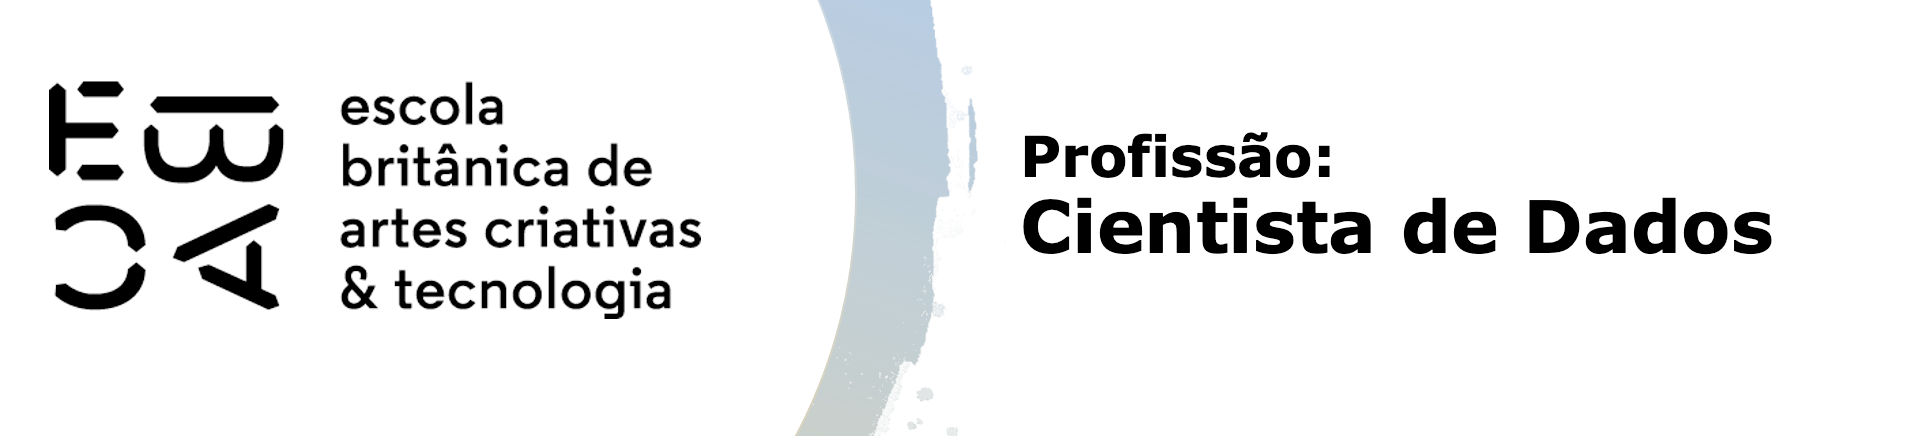

# Regressão III - Tarefa

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import patsy

import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.tsa.x13 import x13_arima_analysis
from scipy.interpolate import interp1d

#%matplotlib inline

In [2]:
df = pd.read_csv('previsao_de_renda_II.csv', index_col=0)
print(df.head(5))

            index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
data_ref                                                              
2015-01-01   5762    M                S               N           0   
2015-01-01   1279    M                S               N           0   
2015-01-01  14111    M                S               N           0   
2015-01-01   8189    M                N               S           2   
2015-01-01   1830    F                N               S           2   

             tipo_renda             educacao estado_civil tipo_residencia  \
data_ref                                                                    
2015-01-01   Empresário    Superior completo       Casado            Casa   
2015-01-01  Assalariado  Superior incompleto       Casado            Casa   
2015-01-01  Assalariado    Superior completo       Casado            Casa   
2015-01-01  Assalariado                Médio       Casado            Casa   
2015-01-01  Assalariado    Superior comp

## Avalie valores missing e substitua pela média

Neste exercício não vamos nos preocupar com valores *missing*. Substitua-os pela média.

In [3]:
print(df.columns)

Index(['index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel', 'qtd_filhos',
       'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade',
       'tempo_emprego', 'qt_pessoas_residencia', 'renda'],
      dtype='object')


In [4]:
print(df.dropna())

            index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
data_ref                                                              
2015-01-01   5762    M                S               N           0   
2015-01-01   1279    M                S               N           0   
2015-01-01  14111    M                S               N           0   
2015-01-01   8189    M                N               S           2   
2015-01-01   1830    F                N               S           2   
...           ...  ...              ...             ...         ...   
2016-03-01   7163    M                N               S           0   
2016-03-01   1487    M                N               N           0   
2016-03-01  11611    F                N               S           1   
2016-03-01  16583    F                N               S           0   
2016-03-01   3024    F                S               S           1   

                  tipo_renda             educacao estado_civil  \
data_ref  

### Base de testes

Separe os três últimos meses como base *holdout* (base de teste).

In [5]:
print(df.index.min())
print(df.index.max())

2015-01-01
2016-03-01


In [6]:
df_train = df[:'2015-12-01']
df_test = df['2016-03-01':]

### Primeiro modelo
 Não use *index* e não use a data. Avalie o modelo com o $R^2-ajustado$

In [7]:
print(df.columns)

Index(['index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel', 'qtd_filhos',
       'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade',
       'tempo_emprego', 'qt_pessoas_residencia', 'renda'],
      dtype='object')


In [8]:
X1 = patsy.dmatrices('''np.log(renda) ~ C(sexo)
                    + C(posse_de_veiculo)
                    + C(posse_de_imovel)
                    + qtd_filhos
                    + C(tipo_renda)
                    + C(educacao, Treatment(2))
                    + C(estado_civil)
                    + C(tipo_residencia, Treatment(1))
                    + idade
                    + tempo_emprego
                    + qt_pessoas_residencia
                    + 1''', df_train)

In [9]:
res = smf.ols(X1, data=df_train).fit_regularized(method='elastic_net', refit=True, L1_wt=1, alpha=0.05)

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:          np.log(renda)   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                 8.864e+04
Date:                Sun, 13 Apr 2025   Prob (F-statistic):               0.00
Time:                        16:38:49   Log-Likelihood:            -6.6752e+05
No. Observations:              499269   AIC:                         1.335e+06
Df Residuals:                  499264   BIC:                         1.335e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

A forma mais fácil de transformar essa tabela em Data Frame (que eu conheço pelo menos) é usar o .to_html para convertê-la em HTML, em seguida usar a função pd.read_html() do pandas. Repare que essa função é feita para ler uma página de internet e encontrar as tabelas (no plural mesmo, mais de uma), e retornar uma lista com todas as tabelas da página. Por isso vamos precisar da indexação final indicando que queremos a primeira tabela (mesmo sendo a única).

Agora vamos usar o ```.style``` do pandas para realçar os *p-values* menores que 5%, colocar vírgula como separador de decimal e 4 casas decimais.

In [10]:
resumo = res.summary()
print(resumo.tables[1])

                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             8.1188      0.006   1251.501      0.000       8.106       8.131
C(sexo)[T.M]                                               0          0        nan        nan           0           0
C(posse_de_veiculo)[T.S]                                   0          0        nan        nan           0           0
C(posse_de_imovel)[T.S]                               0.1780      0.003     64.699      0.000       0.173       0.183
C(tipo_renda)[T.Bolsista]                                  0          0        nan        nan           0           0
C(tipo_renda)[T.Empresário]                                0          0        nan        nan           0           0
C(tipo_renda)[T.Pensionista]                            

In [11]:
print(resumo.tables[1])

                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                                             8.1188      0.006   1251.501      0.000       8.106       8.131
C(sexo)[T.M]                                               0          0        nan        nan           0           0
C(posse_de_veiculo)[T.S]                                   0          0        nan        nan           0           0
C(posse_de_imovel)[T.S]                               0.1780      0.003     64.699      0.000       0.173       0.183
C(tipo_renda)[T.Bolsista]                                  0          0        nan        nan           0           0
C(tipo_renda)[T.Empresário]                                0          0        nan        nan           0           0
C(tipo_renda)[T.Pensionista]                            

In [12]:
tabela = pd.read_html(resumo.tables[1].as_html(), header=0, index_col=0)[0]
tabela.style.format(decimal=',', precision=4) \
    .highlight_between(
    right=.05
    , axis=1
    , props='color:red'
    , subset='P>|t|'
).set_properties(**{'background-color': '#ffffb3'}, subset=['[0.025', '0.975]'])

/tmp/ipykernel_12013/304053529.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tabela = pd.read_html(resumo.tables[1].as_html(), header=0, index_col=0)[0]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,"8,1188","0,0060","1251,5010","0,0000","8,1060","8,1310"
C(sexo)[T.M],"0,0000","0,0000",nan,nan,"0,0000","0,0000"
C(posse_de_veiculo)[T.S],"0,0000","0,0000",nan,nan,"0,0000","0,0000"
C(posse_de_imovel)[T.S],"0,1780","0,0030","64,6990","0,0000","0,1730","0,1830"
C(tipo_renda)[T.Bolsista],"0,0000","0,0000",nan,nan,"0,0000","0,0000"
C(tipo_renda)[T.Empresário],"0,0000","0,0000",nan,nan,"0,0000","0,0000"
C(tipo_renda)[T.Pensionista],"0,0000","0,0000",nan,nan,"0,0000","0,0000"
C(tipo_renda)[T.Servidor público],"0,0000","0,0000",nan,nan,"0,0000","0,0000"
"C(educacao, Treatment(2))[T.Fundamental]","0,0000","0,0000",nan,nan,"0,0000","0,0000"
"C(educacao, Treatment(2))[T.Médio]","0,0000","0,0000",nan,nan,"0,0000","0,0000"


### Análise de perfil

Categorize a variável ```tempo_emprego``` em 20 quantis (cada categoria deve ter aproximadamente a mesma quantidade de observações) e faça uma tabela de perfil (armazene como dataframe) para esta categorização:

- Cada linha é uma categoria
- Uma coluna para a quantidade de observações de cada categoria
- Uma coluna para a média do log-renda para cada categoria
- Uma coluna para a média do tempo de emprego para cada categoria

Faça um gráfico da média do tempo de emprego pela média do log-renda. Insira uma célula de texto e comente se te parece que alguma das transformações vistas no módulo deve fornecer bons resultados.

In [13]:
df_train['tempo_emprego_cat'], quebras = pd.qcut(df_train.tempo_emprego, 20, duplicates='drop', retbins=True)
#df_train['tempo_emprego_cat'], quebras = pd.cut(df_train.tempo_emprego, 20, duplicates='drop', retbins=True)
#df_train['tempo_emprego_cat'], quebras = pd.qcut(df_train.tempo_emprego, 20, duplicates='drop', retbins=True)
print(df_train)

            index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
data_ref                                                              
2015-01-01   5762    M                S               N           0   
2015-01-01   1279    M                S               N           0   
2015-01-01  14111    M                S               N           0   
2015-01-01   8189    M                N               S           2   
2015-01-01   1830    F                N               S           2   
...           ...  ...              ...             ...         ...   
2015-12-01   4650    F                N               S           1   
2015-12-01   9717    M                S               S           0   
2015-12-01   7485    M                S               S           0   
2015-12-01  15500    F                S               S           1   
2015-12-01   1103    F                S               S           1   

                  tipo_renda             educacao estado_civil  \
data_ref  

/tmp/ipykernel_12013/2955365606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['tempo_emprego_cat'], quebras = pd.qcut(df_train.tempo_emprego, 20, duplicates='drop', retbins=True)


In [14]:
print(quebras)

[ 0.11780822  0.68219178  1.19452055  1.76712329  2.36438356  3.04931507
  3.63013699  4.19452055  4.69315068  5.35616438  6.04383562  6.72054795
  7.45753425  8.22739726  9.09315068 10.18082192 11.72328767 13.86575342
 16.54520548 21.47945205 42.90684932]


In [15]:
# Criando tabela de perfil
tab_perfil = pd.DataFrame()

# Coluna para a quantidade de observações de cada categoria
tab_perfil['qtd_obs'] = df_train['tempo_emprego_cat'].value_counts()

# Coluna para a média do log-renda para cada categoria
df_train['log_renda']=np.log(df_train['renda'])

tab_perfil['log_renda_med'] = df_train.groupby('tempo_emprego_cat')['log_renda'].mean()
# Coluna para a média do tempo de emprego para cada categoria

tab_perfil['tempo_emprego_med'] = df_train.groupby('tempo_emprego_cat')['tempo_emprego'].mean()
tab_perfil.sort_index(axis = 0, inplace = True)
tab_perfil.reset_index(inplace=True)
tab_perfil.rename(columns={'index':'tempo_emprego_cat'}, inplace=True)
print(tab_perfil)


               tempo_emprego_cat  qtd_obs  log_renda_med  tempo_emprego_med
0   (0.11699999999999999, 0.682]    25154       8.370907           0.464057
1                 (0.682, 1.195]    25038       8.417388           0.971487
2                 (1.195, 1.767]    24888       8.531471           1.502835
3                 (1.767, 2.364]    24789       8.561743           2.055728
4                 (2.364, 3.049]    25155       8.675957           2.715994
5                  (3.049, 3.63]    24822       8.754188           3.355636
6                  (3.63, 4.195]    24931       8.849051           3.924755
7                 (4.195, 4.693]    25158       8.912516           4.449669
8                 (4.693, 5.356]    24755       8.949442           5.004796
9                 (5.356, 6.044]    24954       9.112963           5.708783
10                (6.044, 6.721]    24982       9.142706           6.400884
11                (6.721, 7.458]    25118       9.239064           7.063921
12          

/tmp/ipykernel_12013/1453696107.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['log_renda']=np.log(df_train['renda'])
/tmp/ipykernel_12013/1453696107.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab_perfil['log_renda_med'] = df_train.groupby('tempo_emprego_cat')['log_renda'].mean()
/tmp/ipykernel_12013/1453696107.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silenc

Legend


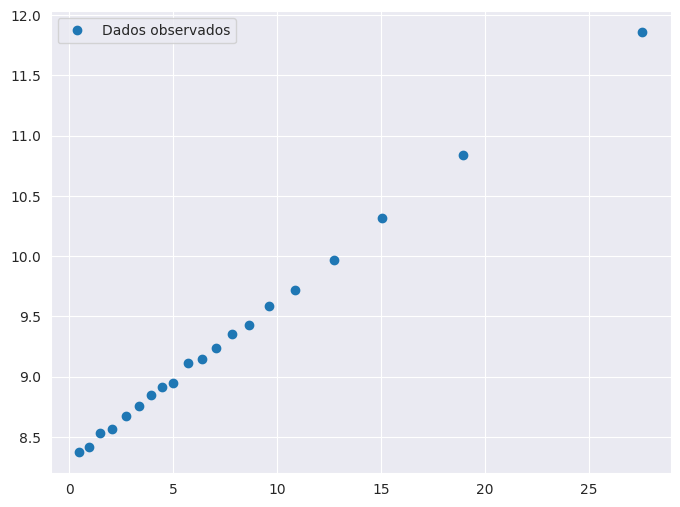

In [16]:


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tab_perfil.tempo_emprego_med, tab_perfil.log_renda_med, "o", label="Dados observados", alpha=1)
print(ax.legend())



### Linearização

Experimente pelo menos duas técnicas de linearização vistas ao longo do módulo para melhorar o ajuste da variável ```tempo_emprego```. Compare o $R^2-ajustado$ e avalie se alguma delas apresentou resultados relevantes com relação ao primeiro modelo.


In [17]:
df_train_b = df_train.merge(tab_perfil, on='tempo_emprego_cat', how='left')
df_train_b.head()

,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,tempo_emprego_cat,log_renda,qtd_obs,log_renda_med,tempo_emprego_med
0,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47,16.717808,2.0,11138.14,"(16.545, 21.479]",9.318131,24753.0,10.835360,18.957327
1,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30,9.600000,2.0,2424.81,"(9.093, 10.181]",7.793508,24886.0,9.585146,9.635562
2,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28,8.208219,2.0,13749.66,"(7.458, 8.227]",9.528769,24953.0,9.353818,7.859614
3,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44,1.301370,4.0,2361.84,"(1.195, 1.767]",7.767196,24888.0,8.531471,1.502835
4,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33,1.254795,4.0,790.78,"(1.195, 1.767]",6.673020,24888.0,8.531471,1.502835


In [18]:
X2 = patsy.dmatrices('''log_renda ~
                    + C(posse_de_imovel)
                    + qtd_filhos
                    + idade
                    + tempo_emprego_cat
                    + 1''', df_train_b)

res_2 = smf.ols(X2, data=df_train_b).fit()
print(f'R-quadrado ajustado: {res_2.rsquared_adj:.2%}')



R-quadrado ajustado: 46.22%


In [19]:
%%time
# Define a suavização dos dados na variável lowess
lowess = sm.nonparametric.lowess(df_train_b.log_renda, df_train_b.tempo_emprego, frac=2/3)

CPU times: user 24.2 s, sys: 2.79 ms, total: 24.2 s
Wall time: 24.3 s


In [20]:
# Valores de X,Y suavizados
lowess_x = lowess[:, 0]
lowess_y = lowess[:, 1]

# Roda a interpolação do scipy
f = interp1d(lowess_x, lowess_y, bounds_error=False)

df_train_b['tempo_emprego_lowess'] = f(df_train_b.tempo_emprego)
df_train_b.head()

,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,tempo_emprego_cat,log_renda,qtd_obs,log_renda_med,tempo_emprego_med,tempo_emprego_lowess
0,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47,16.717808,2.0,11138.14,"(16.545, 21.479]",9.318131,24753.0,10.835360,18.957327,10.528145
1,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30,9.600000,2.0,2424.81,"(9.093, 10.181]",7.793508,24886.0,9.585146,9.635562,9.576349
2,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28,8.208219,2.0,13749.66,"(7.458, 8.227]",9.528769,24953.0,9.353818,7.859614,9.395864
3,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44,1.301370,4.0,2361.84,"(1.195, 1.767]",7.767196,24888.0,8.531471,1.502835,8.483932
4,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33,1.254795,4.0,790.78,"(1.195, 1.767]",6.673020,24888.0,8.531471,1.502835,8.477661


In [21]:
X3 = patsy.dmatrices('''log_renda ~
                    + C(posse_de_imovel)
                    + qtd_filhos
                    + idade
                    + tempo_emprego_lowess
                    + 1''', df_train_b)

res_3 = smf.ols(X3, data=df_train_b).fit()
print(f'R-quadrado ajustado: {res_3.rsquared_adj:.2%}')

R-quadrado ajustado: 47.08%


### Avaliando o modelo

Avalie os resultados dos modelos construidos na base de testes.

In [34]:
# avaliando o modelo test para tempo_emprego
#dividindo em 20 quantis
df_test['tempo_emprego_cat'], quebras = pd.qcut(df_test.tempo_emprego, 20, duplicates='drop', retbins=True)

/tmp/ipykernel_12013/1775451963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['tempo_emprego_cat'], quebras = pd.qcut(df_test.tempo_emprego, 20, duplicates='drop', retbins=True)


In [36]:
print(quebras)

[ 0.11780822  0.68219178  1.18082192  1.75890411  2.30136986  2.97534247
  3.60821918  4.17808219  4.69041096  5.36438356  6.04383562  6.72315068
  7.45753425  8.22739726  9.08465753 10.12739726 11.63287671 13.78082192
 16.38630137 21.23219178 42.90684932]


In [40]:
# agora vamos fazer um mege da tabela perfil
# com base na categorizacao dos valores
df_test_b = df_test.merge(tab_perfil, on='tempo_emprego_cat', how='left')
print(df_test_b.head())

   index sexo posse_de_veiculo posse_de_imovel  qtd_filhos   tipo_renda  \
0  13799    F                S               N           0  Pensionista   
1    694    F                N               S           0  Assalariado   
2  13352    M                S               N           0   Empresário   
3   1152    M                N               S           0  Assalariado   
4   1933    F                N               S           0   Empresário   

            educacao estado_civil tipo_residencia  idade  tempo_emprego  \
0        Fundamental       Casado            Casa     64            NaN   
1              Médio        União            Casa     32      13.865753   
2  Superior completo       Casado            Casa     53       6.602740   
3              Médio     Solteiro            Casa     55       2.846575   
4              Médio       Casado            Casa     42       9.597260   

   qt_pessoas_residencia    renda  log_renda tempo_emprego_cat  qtd_obs  \
0                    2.

AttributeError: 'DataFrame' object has no attribute 'tempo_emprego_lowess'

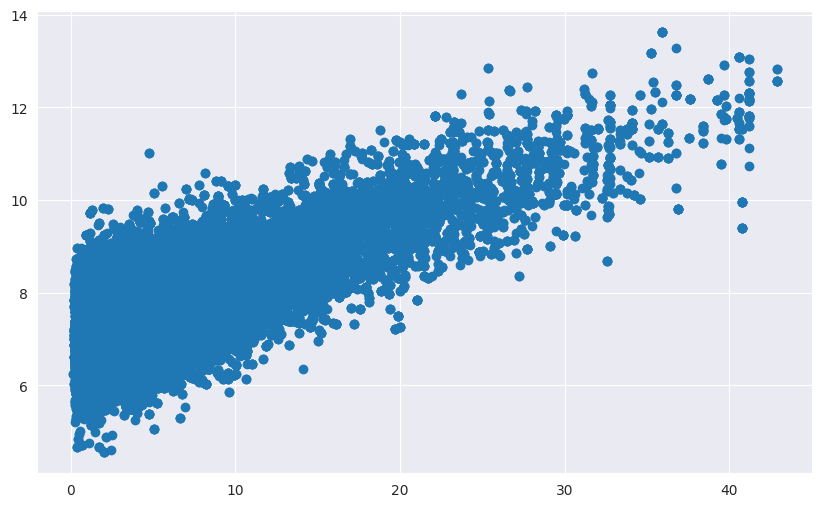

In [48]:
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.figure(figsize=(10, 6))
plt.scatter(df_test_b.tempo_emprego, df_test_b.log_renda, label='Dados observados')
plt.plot(df_test_b.tempo_emprego, df_test_b.tempo_emprego_lowess, label='Modelo linearizado')
plt.plot(df_test_b.tempo_emprego, res_2.fittedvalues, label='Modelo 1')
plt.plot(df_test_b.tempo_emprego, res_3.fittedvalues, label='Modelo 2')
plt.legend()

nesse grafico de dispensao feito com scatter plot podemos a quantidade da dados
junto e aguns disperso esse modelo esta alinhado ele si consetra entre o 0 a 45